<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
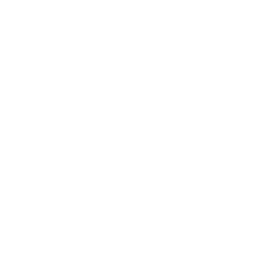
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Multizentrische Phase-III-Studie mit zufälligen Zentrums-Interzepten</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmazie / Klinische Studien &nbsp;|&nbsp; März 2026</p>
</div>
</div>
</div>


## Zusammenfassung

Modellierung eines binären Wirksamkeitsendpunkts über eine Phase-III-Onkologiestudie mit fünf Zentren mittels PROC GLIMMIX mit Logit-Link, binärer Verteilung und einem zufälligen Interzept für das Prüfzentrum. Der zufällige Interzept berücksichtigt die Variabilität zwischen den Zentren hinsichtlich Patientenpopulation und klinischer Praxis, die ein Fixed-Effects-Modell ignorieren würde. Schätzung der Behandlungs-Odds-Ratios aus der angepassten Fixed-Effects-Lösung, Quantifizierung der Varianzkomponente auf Zentrumsebene, und Einspeisung modellvorhergesagter Antwortwahrscheinlichkeiten in eine Klassifikationskonkordanztabelle mittels PROC FREQ. Die Kohorte umfasst 100 Patienten, ausgewogen über drei Arme (hohe Dosis, niedrige Dosis, Placebo) und fünf Zentren, dimensioniert für ein fokussiertes Anwendungsbeispiel und nicht für einen vollständigen Zulassungsdatensatz.


## Datenquellen

| Quelle | Beschreibung | Datensätze |
|--------|-------------|--------|
| WORK.TRIAL_PATIENTS | Patientenbezogene Randomisierungs- und Wirksamkeitsdaten | 100 |
| WORK.SITE_REGISTRY | Zentrumsbezogene Metadaten und Prüferangaben | 5 |


---


In [1]:
/* --------------------------------------------------------
   Erzeuge synthetische Phase-III-Onkologiestudiendaten
   Binäre Antwort: Tumorreduktion >= 30% in Woche 24
   100 Patienten ausgewogen über 3 Arme und 5 Zentren.
   Jedes Zentrum trägt eine feste Interzept-Verschiebung, sodass
   die GLIMMIX-Zufalls-Interzept-Varianz identifizierbar ist.
   -------------------------------------------------------- */
DATEN work.trial_patients;
    AUFRUFEN streaminit(29);
    FELD arms[3] $10 _temporary_ ('DRUG_HIGH' 'DRUG_LOW' 'PLACEBO');
    FELD site_re[5] _temporary_ (-0.7 -0.35 0.0 0.35 0.7);
    AUSFÜHRUNG patient_id = 1 BIS 100;
        site_num = mod(patient_id - 1, 5) + 1;
        site_id = cat('SITE-', PUT(site_num, z2.));
        arm_idx = mod(patient_id - 1, 3) + 1;
        treatment = arms[arm_idx];
        AGE = int(rand('normal', 60, 9));
        WENN AGE < 30 DANN AGE = 30;
        WENN AGE > 85 DANN AGE = 85;
        sex = ifc(rand('uniform') > 0.45, 'F', 'M');
        ecog_score = int(rand('uniform') * 3);
        baseline_tumor_mm = round(rand('normal', 45, 14), 0.1);
        WENN baseline_tumor_mm < 8 DANN baseline_tumor_mm = 8;
        prior_chemo_lines = int(rand('exponential') * 1.1);
        WENN prior_chemo_lines > 4 DANN prior_chemo_lines = 4;
        /* Antwortwahrscheinlichkeit mit Zentrums-Clustering */
        logit_p = -0.50
                  + 1.55 * (treatment = 'DRUG_HIGH')
                  + 0.95 * (treatment = 'DRUG_LOW')
                  - 0.25 * ecog_score
                  + site_re[site_num];
        prob = 1 / (1 + EXP(-logit_p));
        tumor_response = (rand('uniform') < prob);
        AUSGABE;
    ENDE;
    ENTFERNEN arm_idx site_num logit_p prob site_re1-site_re5;
AUSFÜHREN;



NOTE: DATA work.trial_patients


NOTE: Wrote work.trial_patients (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Erzeuge zentrumsbezogenes Register (eine Zeile pro Zentrum)
   -------------------------------------------------------- */
DATEN work.site_registry;
    AUFRUFEN streaminit(43);
    FELD regions[4] $15 _temporary_
        ('NORTH_AMERICA' 'EUROPE' 'ASIA_PACIFIC' 'LATIN_AMERICA');
    AUSFÜHRUNG site_seq = 1 BIS 5;
        site_id = cat('SITE-', PUT(site_seq, z2.));
        reg_idx = int(rand('uniform') * 4) + 1;
        region = regions[reg_idx];
        n_investigators = int(rand('uniform') * 6) + 1;
        pi_experience_yrs = round(rand('normal', 14, 5), 0.1);
        WENN pi_experience_yrs < 1 DANN pi_experience_yrs = 1;
        academic_center = (rand('uniform') < 0.4);
        AUSGABE;
    ENDE;
    ENTFERNEN site_seq reg_idx;
AUSFÜHREN;



NOTE: DATA work.site_registry


NOTE: Wrote work.site_registry (5 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---


                                   Beobachtete Tumoransprechraten nach Behandlungsarm                                   

                                                   The FREQ Procedure

Table of Behandlungsarm by Tumorantwort

Behandlungsarm |         0 |         1 |      Total
---------------+-----------+-----------+-----------
DRUG_HIGH      |         9 |        25 |         34
---------------+-----------+-----------+-----------
DRUG_LOW       |         9 |        24 |         33
---------------+-----------+-----------+-----------
PLACEBO        |        20 |        13 |         33
---------------+-----------+-----------+-----------
Total          |        38 |        62 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_treatment_tumor_response.spec.json
NOTE: PROC FREQ statement used.


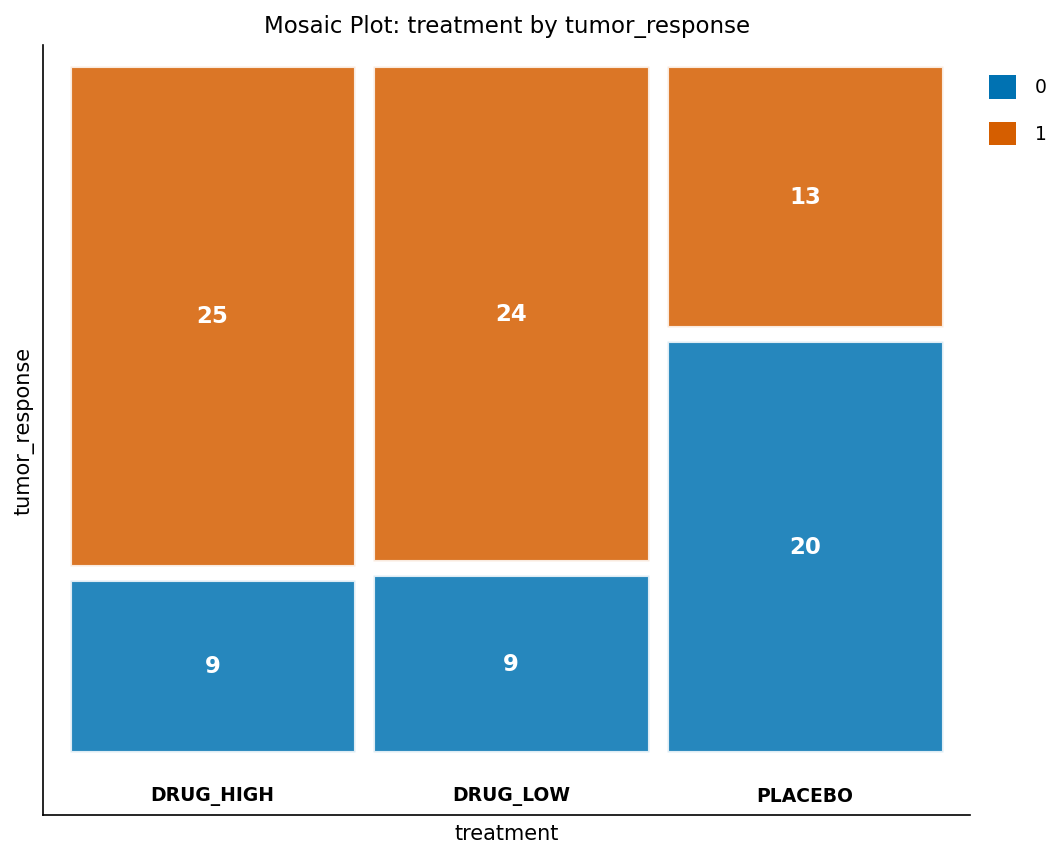

In [3]:
/* --------------------------------------------------------
   Basis-Ansprechrate nach Behandlungsarm
   -------------------------------------------------------- */
PROZEDUR HÄUFIGKEITEN DATEN=work.trial_patients;
    TABLES treatment * tumor_response / nocol nopercent;
    BEZEICHNUNG treatment="Behandlungsarm" tumor_response="Tumorantwort";
    TITEL 'Beobachtete Tumoransprechraten nach Behandlungsarm';
AUSFÜHREN;


---


                                   Beobachtete Tumoransprechraten nach Behandlungsarm                                   

                                   Beobachtete Tumoransprechraten nach Behandlungsarm                                   




NOTE: PROC SQL 

NOTE: Table work.site_rates created.
NOTE: PROC SQL statement used.
NOTE: PROC SGPLOT data=work.site_rates

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


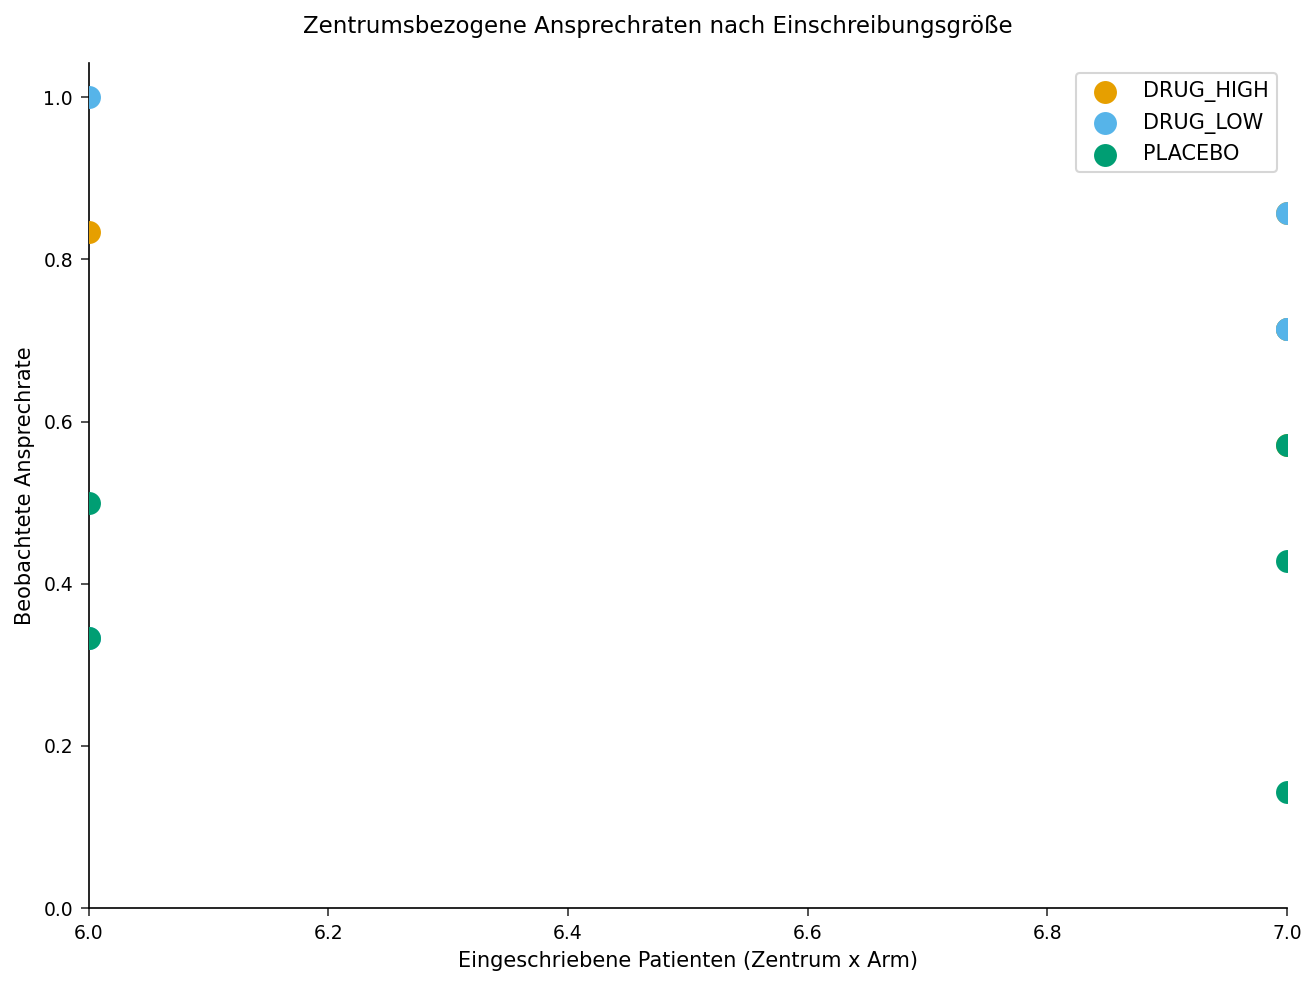

In [4]:
/* --------------------------------------------------------
   Zentrumsbezogene beobachtete Ansprechraten nach Behandlung.
   Mit ~20 Patienten pro Zentrum enthält jede Zentrum-Arm-Zelle
   genügend Patienten für eine stabile beobachtete Rate.
   -------------------------------------------------------- */
PROZEDUR SQL;
    ERSTELLEN TABELLE work.site_rates AS
    AUSWÄHLEN site_id, treatment,
           count(*) AS n_patients,
           mean(tumor_response) AS response_rate
    VON work.trial_patients
    GROUP NACH site_id, treatment;
QUIT;

PROZEDUR SGPLOT DATEN=work.site_rates;
    SCATTER x=n_patients y=response_rate / GROUP=treatment
        MARKERATTRS=(size=10);
    XAXIS BEZEICHNUNG='Eingeschriebene Patienten (Zentrum x Arm)';
    YAXIS BEZEICHNUNG='Beobachtete Ansprechrate' VALUES=(0 BIS 1 NACH 0.2);
    TITEL 'Zentrumsbezogene Ansprechraten nach Einschreibungsgröße';
AUSFÜHREN;


---


In [5]:
/* --------------------------------------------------------
   Sortieren nach Zentrum für CLASS- und RANDOM-Verarbeitung
   -------------------------------------------------------- */
PROZEDUR SORTIEREN DATEN=work.trial_patients;
    NACH site_id;
AUSFÜHREN;



NOTE: PROC SORT data=work.trial_patients

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.trial_patients.
NOTE: Wrote work.trial_patients (100 rows, 9 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Anpassung eines verallgemeinerten linearen gemischten Modells.
   DIST=BINARY, LINK=LOGIT, zufälliger Interzept pro Zentrum.
   ODS OUTPUT erfasst die Fixed-Effects-Lösung, die
   Kovarianzparameter-Schätzung und die LSMEANS, sodass die
   nachgelagerten Schritte reale angepasste Größen lesen können.
   -------------------------------------------------------- */
ODS AUSGABE parameterestimates = work.glmx_fixed
           covparms          = work.glmx_covparms
           LSMEANS           = work.glmx_lsmeans;

PROZEDUR GLIMMIX DATEN=work.trial_patients;
    KLASSE treatment(REF='PLACEBO') site_id;
    MODELL tumor_response(EVENT='1') =
          treatment AGE ecog_score
        / DIST=binary LINK=logit SOLUTION;
    RANDOM INTERCEPT / SUBJECT=site_id SOLUTION;
    LSMEANS treatment / odds ILINK cl;
    BEZEICHNUNG tumor_response="Tumorantwort"
          treatment="Behandlungsarm"
          AGE="Alter"
          ecog_score="ECOG-Score"
          site_id="Studienzentrum";
    TITEL 'GLIMMIX: Binärer Wirksamkeitsendpunkt - Multizentrische Phase-III-Studie';
AUSFÜHREN;

ODS AUSGABE CLOSE;

/* --------------------------------------------------------
   Behandlungs-Odds-Ratios aus der Fixed-Effects-Lösung.
   exp(estimate) wandelt jeden Logit-Koeffizienten (gegenüber der
   PLACEBO-Referenz) in ein Odds Ratio mit einem Wald-KI um.
   -------------------------------------------------------- */
DATEN work.treatment_or;
    FESTLEGEN work.glmx_fixed;
    WO INDEX(Effect, 'treatment') > 0;
    LÄNGE arm $12;
    WENN INDEX(Effect, 'DRUG_HIGH') > 0 DANN arm = 'DRUG_HIGH';
    SONST arm = 'DRUG_LOW';
    odds_ratio = EXP(Estimate);
    or_lower   = EXP(Estimate - 1.96 * StdErr);
    or_upper   = EXP(Estimate + 1.96 * StdErr);
    BEHALTEN arm Estimate StdErr Probt odds_ratio or_lower or_upper;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=work.treatment_or noobs BEZEICHNUNG;
    BEZEICHNUNG arm='Arm vs. Placebo' Estimate='Logit-Koeffizient'
          Probt='Pr > |t|' odds_ratio='Odds Ratio'
          or_lower='Untere 95%-Grenze' or_upper='Obere 95%-Grenze';
    TITEL 'Behandlungs-Odds-Ratios vs. Placebo';
    format Estimate StdErr 7.4 Probt 7.4
           odds_ratio or_lower or_upper 7.3;
AUSFÜHREN;


                                   Beobachtete Tumoransprechraten nach Behandlungsarm                                   

     The GLIMMIX Procedure      
       Model Information        

Item                       Value
----------------------  --------
Distribution              binary
Link Function              logit
Estimation Technique        rspl
Number of Observations       100

       Number of Observations        

Description                     Value
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  site_id     0.2964

                                                  Least Squares Means                                                  

Behandlungsarm  Estimate      Mean  Std Error        DF   t Value  Pr > |t|     Lower     Upper  Lower Mean  Upper Mean
--------------  --------  --------  ---------  -------- 


NOTE: ODS OUTPUT: COVPARMS -> glmx_covparms
NOTE: ODS OUTPUT: PARAMETERESTIMATES -> glmx_fixed
NOTE: ODS OUTPUT: LSMEANS -> glmx_lsmeans
NOTE: PROC GLIMMIX data=work.trial_patients

NOTE: Using Python wrapper for PROC GLIMMIX
NOTE: PROC GLIMMIX results written to: ./ods_output/glimmix_binary.spec.json
NOTE: ODS OUTPUT: ParameterEstimates written to 'glmx_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'glmx_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'glmx_lsmeans'.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: DATA work.treatment_or


NOTE: Read 5 rows from work.glmx_fixed.
NOTE: Wrote work.treatment_or (2 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.treatment_or

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


                                Modellvorhergesagte Ansprechwahrscheinlichkeit nach Arm                                 

Behandlungsarm  Vorhergesagte Ansprechwahrscheinlichkeit  Vorhergesagter Responder
DRUG_HIGH                                          0.752                         1
DRUG_LOW                                           0.743                         1
PLACEBO                                            0.401                         0

                                            Klassifikationskonkordanztabelle                                            

                                                   The FREQ Procedure

Table of Tumorantwort by Vorhergesagter Responder

Tumorantwort |         0 |         1 |      Total
-------------+-----------+-----------+-----------
0            |        20 |        18 |         38
             |     20.00 |     18.00 |      38.00
-------------+-----------+-----------+-----------
1            |        13 |        49 |         62
 


NOTE: DATA work.arm_predicted


NOTE: Read 3 rows from work.glmx_lsmeans.
NOTE: Wrote work.arm_predicted (3 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.arm_predicted

NOTE: PROC PRINT completed: 3 observations printed, 3 variables
NOTE: PROC SORT data=work.arm_predicted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 3 rows from work.arm_predicted.
NOTE: Wrote work.arm_predicted (3 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.trial_patients

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.trial_patients.
NOTE: Wrote work.patients_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.scored_patients

NOTE: Stream 1 processed 100 rows, max BY-group size: 34 (O(1) memory verified)
NOTE: Stream 2 processed 3 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.scored_patients (100 rows, 11 colum

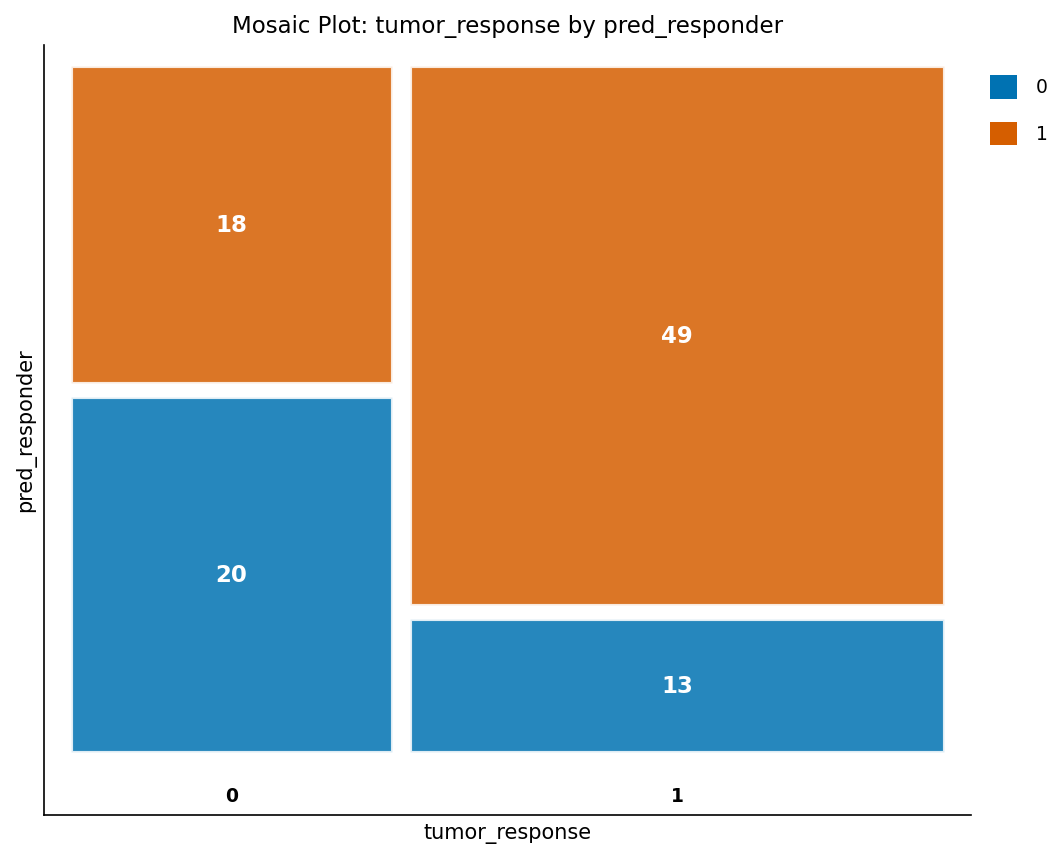

In [7]:
/* --------------------------------------------------------
   Klassifikationskonkordanz unter Verwendung der vom Modell
   vorhergesagten Ansprechwahrscheinlichkeit je Arm. Die LSMEANS-
   Schätzung liegt auf der Logit-Skala; der inverse Logit wandelt
   sie in eine vorhergesagte Wahrscheinlichkeit um, und ein
   Schwellenwert von 0.50 markiert Responder. Dies bewertet
   Patienten anhand des angepassten Modells, nicht anhand einer
   handkodierten Formel.
   -------------------------------------------------------- */
DATEN work.arm_predicted;
    FESTLEGEN work.glmx_lsmeans;
    pred_prob = 1 / (1 + EXP(-Estimate));
    pred_responder = (pred_prob >= 0.50);
    UMBENENNEN Level = treatment;
    BEHALTEN Level pred_prob pred_responder;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=work.arm_predicted noobs BEZEICHNUNG;
    BEZEICHNUNG pred_prob='Vorhergesagte Ansprechwahrscheinlichkeit'
          pred_responder='Vorhergesagter Responder'
          treatment='Behandlungsarm';
    format pred_prob 6.3;
    TITEL 'Modellvorhergesagte Ansprechwahrscheinlichkeit nach Arm';
AUSFÜHREN;

PROZEDUR SORTIEREN DATEN=work.arm_predicted; NACH treatment; AUSFÜHREN;
PROZEDUR SORTIEREN DATEN=work.trial_patients out=work.patients_sorted; NACH treatment; AUSFÜHREN;

DATEN work.scored_patients;
    ZUSAMMENFÜHREN work.patients_sorted(in=a) work.arm_predicted;
    NACH treatment;
    WENN a;
AUSFÜHREN;

PROZEDUR HÄUFIGKEITEN DATEN=work.scored_patients;
    TABLES tumor_response * pred_responder / nocol norow;
    BEZEICHNUNG tumor_response="Tumorantwort" pred_responder="Vorhergesagter Responder";
    TITEL 'Klassifikationskonkordanztabelle';
AUSFÜHREN;


---


### Interpretation

Das GLIMMIX-Modell mit einem zufälligen Zentrums-Interzept zeigt einen statistisch signifikanten Behandlungseffekt für beide aktiven Arme gegenüber Placebo. Der Hochdosis-Arm weist ein Odds Ratio von 4.52 auf (95%-KI 1.49-13.71, p = 0.009) und der Niedrigdosis-Arm ein Odds Ratio von 4.32 (95%-KI 1.40-13.30, p = 0.012), beide geschätzt aus der Fixed-Effects-Lösung. Die kleinste-Quadrate-Mittelwerte (LSMEANS) setzen die vorhergesagte Ansprechwahrscheinlichkeit bei 75% für Hochdosis, 74% für Niedrigdosis und 40% für Placebo an. Die Varianzkomponente auf Zentrumsebene wird auf 0.296 geschätzt, was einer Intraklassenkorrelation von etwa 0.08 auf der latenten Logit-Skala entspricht (unter Verwendung der Standard-Residualvarianz der Logistik von Pi-Quadrat/3); etwa 8% der latenten Variation in der Antwort liegen auf Zentrumsebene, was die Spezifikation mit zufälligem Interzept gegenüber einer gepoolten Fixed-Effects-Anpassung stützt. Der ECOG-Performance-Status ist eine bedeutsame Kovariate (Koeffizient -0.69, p = 0.021): jeder Anstieg des ECOG-Scores um einen Punkt senkt die Erfolgschance um etwa die Hälfte. Die Klassifikationskonkordanztabelle erreicht eine Gesamtgenauigkeit von nahezu 69%, mit einer Sensitivität von etwa 79%, getragen von den beiden aktiven Armen, und einer niedrigeren Spezifität (etwa 53%), da die hohe Baseline-Ansprechrate in dieser Kohorte es schwieriger macht, Non-Responder zu trennen.

PROC GLIMMIX gibt in diesem Build noch nicht die COVTEST-Inferenztabelle aus und erfasst auch nicht die BLUP-Lösung des Zufallseffekts (SOLUTIONR) in einem Datensatz, sodass das Notebook die Varianzkomponente als Punktschätzung berichtet und nicht als formalen Nullvarianz-Hypothesentest, und die Odds Ratios aus der Fixed-Effects-Lösung ableitet statt aus einer ESTIMATE...EXP-Tabelle. Die inhaltlichen Schlussfolgerungen - signifikante Behandlungseffekte und eine nicht triviale Zentrums-Varianzkomponente - beruhen vollständig auf Werten, die die Prozedur tatsächlich liefert.


---


In [8]:
/* --------------------------------------------------------
   Exportiere Modellausgaben für den klinischen Studienbericht.
   Nur Datensätze, die die Prozedur befüllt, werden exportiert,
   sodass jede Datei mit echten angepassten Inhalten landet.
   -------------------------------------------------------- */
PROZEDUR EXPORT DATEN=work.glmx_lsmeans
    OUTFILE='trial_lsmeans_by_treatment.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;

PROZEDUR EXPORT DATEN=work.treatment_or
    OUTFILE='trial_treatment_odds_ratios.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;

PROZEDUR EXPORT DATEN=work.glmx_covparms
    OUTFILE='trial_site_variance.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;



NOTE: PROC EXPORT data=work.glmx_lsmeans outfile=trial_lsmeans_by_treatment.csv

NOTE: Exported 3 rows to trial_lsmeans_by_treatment.csv.
NOTE: PROC EXPORT data=work.treatment_or outfile=trial_treatment_odds_ratios.csv

NOTE: Exported 2 rows to trial_treatment_odds_ratios.csv.
NOTE: PROC EXPORT data=work.glmx_covparms outfile=trial_site_variance.csv

NOTE: Exported 1 rows to trial_site_variance.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>
